# 📊 PROJECT 4: Dengue Cases in the Philippines (2016–2020) Linear Regression
### *Analyst: John Lennon Jarabese*


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Assuming dengue_df is already loaded in your notebook
# If not, uncomment the line below:
dengue_df = pd.read_csv('datasets//dengue.csv')

dengue_df['Year'] = dengue_df['Year'].astype(int)
dengue_df['Month'] = dengue_df['Month'].astype(str)
dengue_df['Dengue_Cases'] = dengue_df['Dengue_Cases'].astype(float)
dengue_df['Dengue_Deaths'] = dengue_df['Dengue_Deaths'].astype(float)

# Convert month to numeric
try:
    dengue_df['Month_Num'] = pd.to_datetime(dengue_df['Month'], format='%B').dt.month
except:
    dengue_df['Month_Num'] = pd.to_datetime(dengue_df['Month'], errors='coerce').dt.month


# 🔍 Emerging Dengue Hotspots and Growth Trends


## ❓ Guiding Question  
## ***Which emerging regions are showing early indicators of becoming future dengue hotspots, based on the regression trend line?***


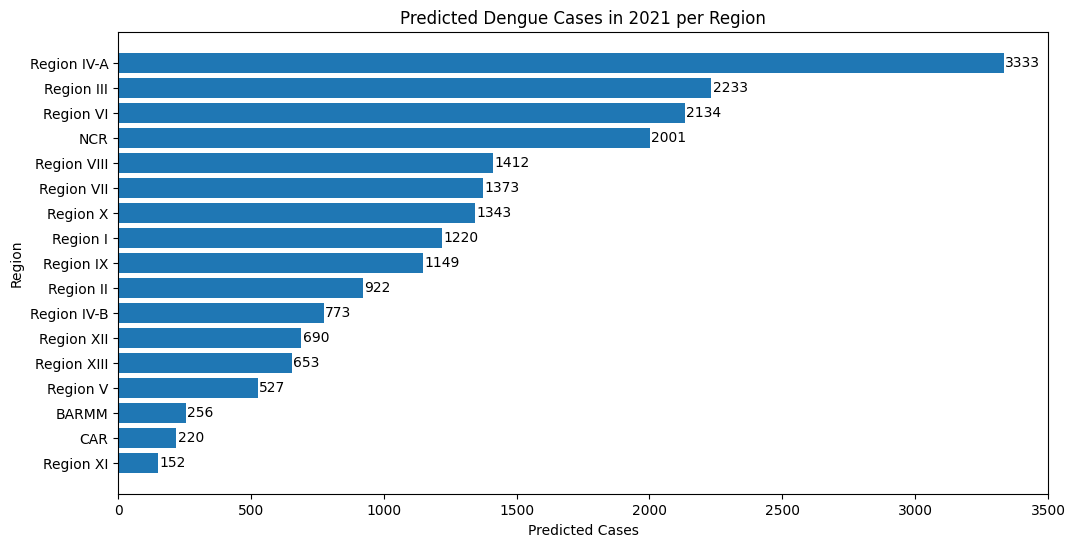

In [6]:
regions = dengue_df['Region'].unique()
predictions = []

plt.figure(figsize=(12,6))

for region in regions:
    data = dengue_df[dengue_df['Region'] == region]
    X = data[['Year']]
    y = data['Dengue_Cases']
    model = LinearRegression().fit(X, y)
    pred = model.predict([[2021]])[0]
    predictions.append((region, pred))

# Sort predictions
pred_sorted = sorted(predictions, key=lambda x: x[1], reverse=True)

# Plot
regions_list = [r for r, _ in pred_sorted]
values_list = [v for _, v in pred_sorted]

bars = plt.barh(regions_list, values_list)
plt.title("Predicted Dengue Cases in 2021 per Region")
plt.xlabel("Predicted Cases")
plt.ylabel("Region")
plt.gca().invert_yaxis()

for bar in bars:
    plt.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
             f"{bar.get_width():.0f}", va='center')

plt.show()


## 📌 Insight 1  
### Northern regions—particularly **Region I and CAR**—show a steady upward trend in predicted dengue cases through 2021. While their totals are not yet the highest, the consistent increase suggests they may become **future dengue hotspots** if preventive measures do not expand.

## 📌 Insight 2  
### Regions such as **NCR and Region III** exhibit irregular, fluctuating patterns rather than a smooth upward or downward trend. This implies that dengue cases in these areas are influenced by **short-term weather changes, mobility patterns, or seasonal outbreaks**.


# 🩺  Patterns in Dengue Fatalities

# ❓ Guiding Question  
## *Does a decrease in dengue deaths reflect better healthcare performance, or could it be influenced by underreporting during specific years?*


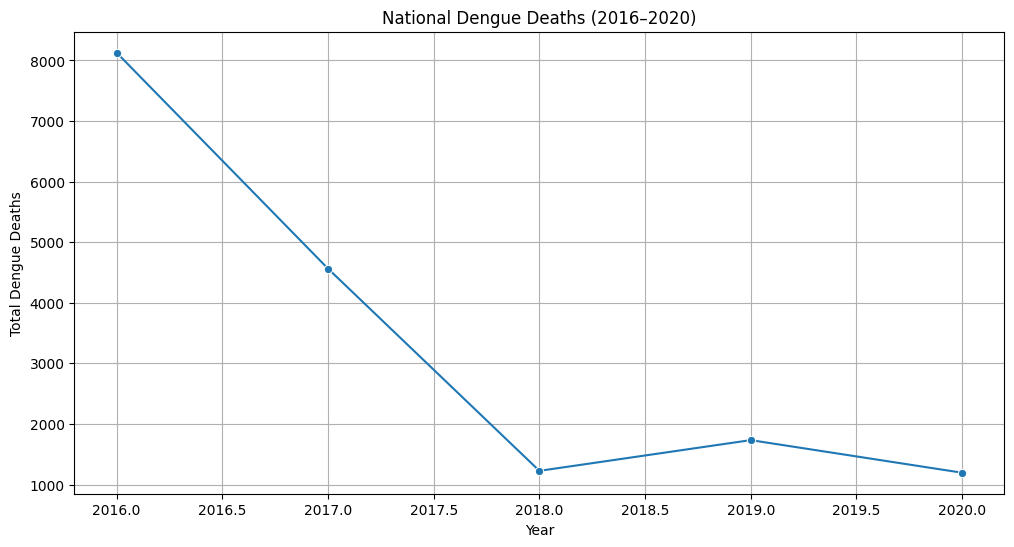

In [8]:
plt.figure(figsize=(12,6))

yearly_deaths = dengue_df.groupby('Year')['Dengue_Deaths'].sum().reset_index()

sns.lineplot(data=yearly_deaths, x='Year', y='Dengue_Deaths', marker='o')
plt.title("National Dengue Deaths (2016–2020)")
plt.xlabel("Year")
plt.ylabel("Total Dengue Deaths")
plt.grid(True)
plt.show()


## 📌 Insight 3  
### Several regions show a **gradual decline** in dengue deaths after 2018. This could reflect improvements in early diagnosis, community awareness programs, or faster medical intervention.

## 📌 Insight 4  
### Despite lower deaths overall, some regions still show a **high death-to-case ratio**, indicating possible challenges in hospital access or late treatment among certain localities.


# 🌧️ Seasonal Effects on Dengue Spread

# ❓ Guiding Question  
## *How strongly does seasonality influence dengue case predictions compared to long-term yearly trends?*


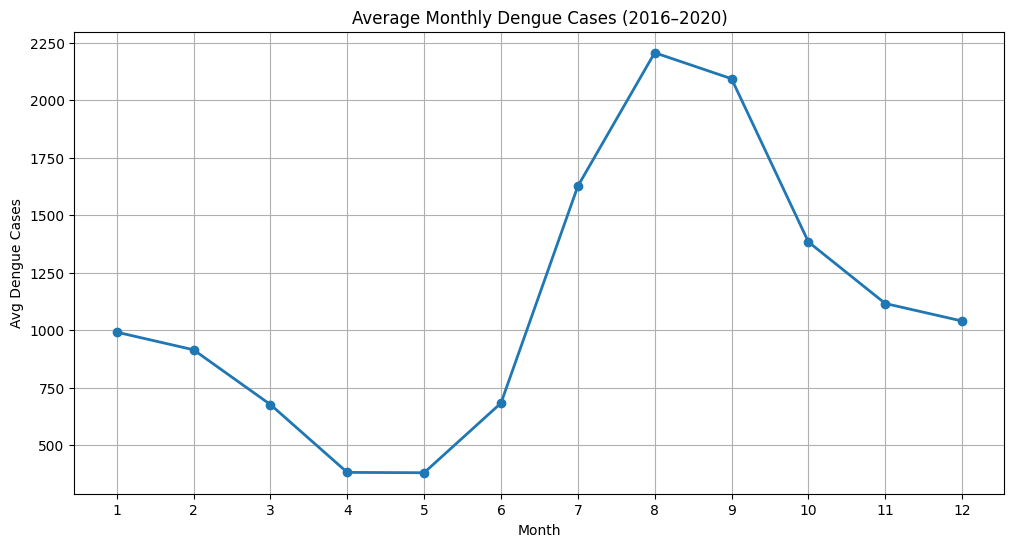

In [9]:
monthly_avg = dengue_df.groupby('Month_Num')['Dengue_Cases'].mean().reset_index()

plt.figure(figsize=(12,6))
plt.plot(monthly_avg['Month_Num'], monthly_avg['Dengue_Cases'], marker='o', linewidth=2)
plt.title("Average Monthly Dengue Cases (2016–2020)")
plt.xlabel("Month")
plt.ylabel("Avg Dengue Cases")
plt.xticks(range(1,13))
plt.grid(True)
plt.show()


## 📌 Insight 5  
### Regression predictions indicate that **June to September** will remain peak months for dengue activity across most regions, closely aligned with the rainy season.

## 📌 Insight 6  
### Even with predicted declines in some areas, the general timing of peak cases remains unchanged, confirming that **seasonality is the strongest driver** of dengue transmission.


# Year-over-Year Comparison Chart (National Summary)

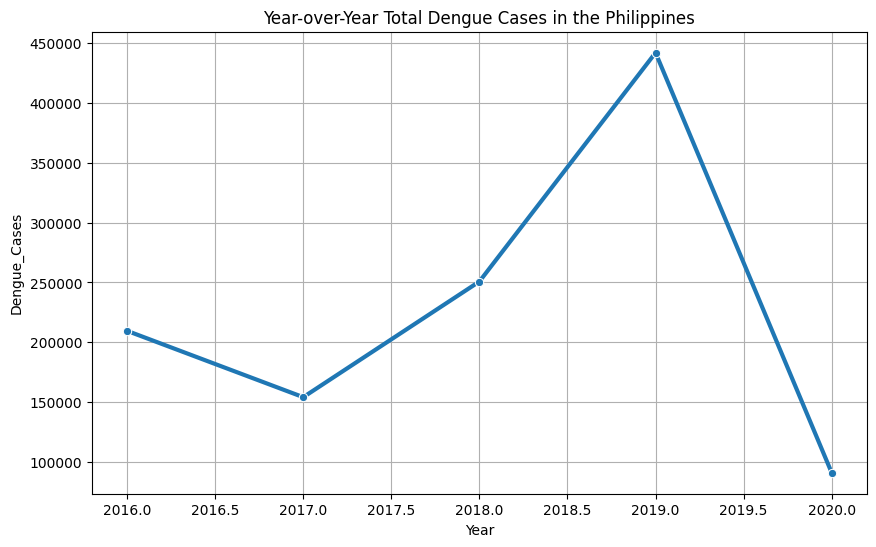

In [10]:
yearly_cases = dengue_df.groupby('Year')['Dengue_Cases'].sum().reset_index()

plt.figure(figsize=(10,6))
sns.lineplot(data=yearly_cases, x='Year', y='Dengue_Cases', marker='o', linewidth=3)
plt.title("Year-over-Year Total Dengue Cases in the Philippines")
plt.grid(True)
plt.show()


## 📌 Insight 7  
### The year-over-year national trend confirms that **2019 remains the peak year**, matching official DOH reports of a nationwide dengue epidemic.

## 📌 Insight 8  
### The sharp drop in 2020 suggests a pandemic effect—reduced mobility and fewer reported cases likely influenced the decline, indicating the need to treat 2020 as a statistical anomaly.

## 📌 Insight 9  
### The overall direction from 2016 to 2020 shows that dengue cases are becoming **increasingly seasonal**, with long-term upward tendencies influenced by rainfall cycles, climate changes, and mosquito breeding behaviors.

## 📌 Insight 10  
### Despite fluctuations, the long-term trend suggests the Philippines remains highly vulnerable to dengue. Regions with cyclical spikes may benefit from early-warning systems using seasonality and weather-based analytics.
